# Lab 5: MNIST CNN Classifier

**COMP 395 — Deep Learning**
**Due: March 20, 2026**
**Individual assignment**

---

## Overview

In this lab you will train convolutional neural networks to classify handwritten digits from the MNIST dataset. You will start by training an MLP baseline, then build and train the `SimpleCNN` from our in-class lab, and finally experiment with architectural modifications — all tracked with MLflow.

This lab is intentionally less scaffolded than previous labs. You have done every individual piece before (data loading, training loops, evaluation, MLflow logging). The challenge here is putting them together independently in a new context.

## Setup

You will need the following libraries. Refer to your earlier labs if you don't remember how any of these work.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import mlflow
import mlflow.pytorch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Part 1: Data Loading and Preprocessing

We load the MNIST dataset using `torchvision`. The key steps:

- `transforms.ToTensor()` converts PIL images to PyTorch tensors and scales pixel values from [0, 255] to [0, 1]. It also rearranges the shape to `(C, H, W)` — the format `nn.Conv2d` expects.
- `transforms.Normalize((0.1307,), (0.3081,))` standardizes using the MNIST dataset's global mean and standard deviation. This centers the data around zero, which helps training converge faster.
- We create separate `DataLoader`s for training and testing. The training loader shuffles; the test loader does not (shuffling the test set would change nothing about evaluation, but ordered data is easier to inspect).

In [2]:
# Preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                        # PIL -> tensor, scales to [0, 1], shape (1, 28, 28)
    transforms.Normalize((0.1307,), (0.3081,)),   # standardize with MNIST mean/std
])

# Download and load MNIST
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

# Create DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Batch size:       {batch_size}")

Training samples: 60000
Test samples:     10000
Batch size:       64


### 1.1 Understanding the DataLoader

Before you start training, take a moment to understand what the `DataLoader` is actually giving you. A `DataLoader` wraps a dataset and provides:

- **Batching:** instead of feeding one image at a time, it groups images into batches (e.g., 64 at once). This is more efficient for the GPU and provides a more stable gradient estimate.
- **Shuffling:** randomizes the order each epoch so the model doesn't memorize the sequence.
- **An iterator:** you loop over it with `for images, labels in dataloader:` and it yields one batch at a time.

Run the cell below to inspect what comes out of the DataLoader.

In [4]:
# Grab one batch from the training DataLoader
images, labels = next(iter(train_loader))

print(f"Batch of images shape: {images.shape}")
print(f"Batch of labels shape: {labels.shape}")
print(f"Label dtype: {labels.dtype}")
print()

# Unpack the shape
N, C, H, W = images.shape
print(f"  N = {N}  (batch size — number of images in this batch)")
print(f"  C = {C}  (channels — 1 for grayscale, 3 for RGB)")
print(f"  H = {H}  (height in pixels)")
print(f"  W = {W}  (width in pixels)")
print()

# Pixel value range after your transforms
print(f"Pixel value range: [{images.min():.4f}, {images.max():.4f}]")
print(f"  (If you normalized with mean=0.1307, std=0.3081,")
print(f"   these won't be [0,1] anymore — that's expected.)")
print()

# What does one label look like?
print(f"First 10 labels in this batch: {labels[:10].tolist()}")
print(f"  (These are integers 0-9, one per image.)")

Batch of images shape: torch.Size([64, 1, 28, 28])
Batch of labels shape: torch.Size([64])
Label dtype: torch.int64

  N = 64  (batch size — number of images in this batch)
  C = 1  (channels — 1 for grayscale, 3 for RGB)
  H = 28  (height in pixels)
  W = 28  (width in pixels)

Pixel value range: [-0.4242, 2.8215]
  (If you normalized with mean=0.1307, std=0.3081,
   these won't be [0,1] anymore — that's expected.)

First 10 labels in this batch: [9, 7, 6, 3, 7, 2, 2, 6, 4, 3]
  (These are integers 0-9, one per image.)


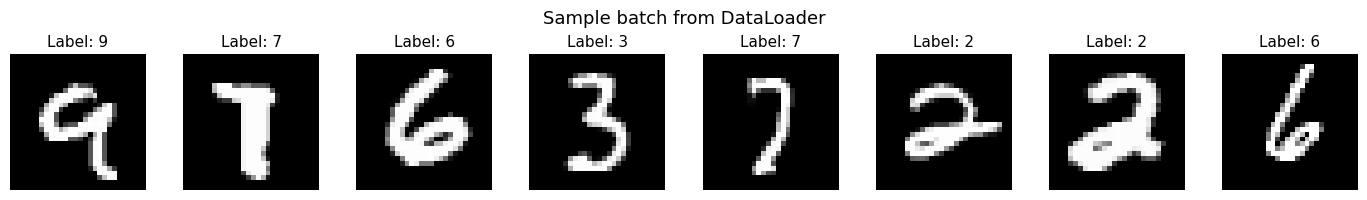

In [5]:
# Visualize a few images from the batch to confirm everything looks right
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i in range(8):
    # images[i] has shape (C, H, W) — squeeze out the channel dim for grayscale
    img = images[i].squeeze().numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}", fontsize=11)
    axes[i].axis('off')
plt.suptitle("Sample batch from DataLoader", fontsize=13)
plt.tight_layout()
plt.show()

### 1.2 How the DataLoader fits into training

When you write a training loop, the DataLoader is what you iterate over:

```python
for epoch in range(num_epochs):
    for images, labels in train_loader:   # <-- one batch at a time
        outputs = model(images)            # forward pass on the batch
        loss = criterion(outputs, labels)  # compute loss for the batch
        ...
```

Each call to the loop yields a fresh batch. After you've gone through every batch once, that's one **epoch**. The DataLoader handles all the bookkeeping of which samples have been used, reshuffling, etc.

**Checkpoint:** Before moving on, make sure you can answer:

1. What is the shape of a single batch of images from your DataLoader?
2. What do the labels look like — are they integers or one-hot vectors?
3. How many batches are in one epoch? (Hint: `len(train_loader)`)

---

In [6]:
# How many batches per epoch?
print(f"Training batches per epoch: {len(train_loader)}")
print(f"  = {len(train_loader.dataset)} images / {train_loader.batch_size} per batch")

Training batches per epoch: 938
  = 60000 images / 64 per batch


## Part 2: MLP Baseline

Before building a CNN, we train a simple MLP on MNIST as a baseline. This gives you a point of comparison and — just as importantly — establishes the training loop and evaluation code that you'll reuse for every experiment that follows.

Study this section carefully. For Parts 3–5, you'll swap in a different model but keep everything else.

### 2.1 Model Definition

The MLP flattens each 28×28 image into a 784-dimensional vector and passes it through fully connected layers. This throws away all spatial structure — the model has no idea that pixel (0,0) is next to pixel (0,1). That's exactly the limitation CNNs will fix.

In [7]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()              # (N, 1, 28, 28) -> (N, 784)
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)                         # raw logits — no softmax here
        return x

mlp_model = MLP()

# Count parameters
total_params = sum(p.numel() for p in mlp_model.parameters())
print(f"MLP parameters: {total_params:,}")
print(f"  fc1: 784 × 256 + 256 = {784*256 + 256:,}")
print(f"  fc2: 256 × 128 + 128 = {256*128 + 128:,}")
print(f"  fc3: 128 × 10  + 10  = {128*10 + 10:,}")

MLP parameters: 235,146
  fc1: 784 × 256 + 256 = 200,960
  fc2: 256 × 128 + 128 = 32,896
  fc3: 128 × 10  + 10  = 1,290


### 2.2 Training Loop

This is the same train loop pattern from Lab 4. We use cross-entropy loss (which expects raw logits, not softmax outputs) and Adam optimizer.

We also define an `evaluate` function that we'll reuse for every experiment.

In [9]:
def evaluate(model, data_loader):
    """Compute accuracy and collect all predictions for a model on a DataLoader."""
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    return accuracy, np.array(all_preds), np.array(all_labels)


In [10]:
# Added in the refactor for Part 3:
# this reusable helper replaces the old model-specific training loop that used to live only in Part 2.
def train_model(model, train_loader, test_loader, num_epochs, learning_rate):
    """Train a classifier and return the loss history."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    loss_history = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)

        # Keep the same progress-print behavior that the deleted inline Part 2 loop had.
        if (epoch + 1) % 2 == 0 or epoch == 0:
            acc, _, _ = evaluate(model, test_loader)
            print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f}  Test Acc: {acc:.4f}")

    return loss_history

In [11]:
# Training setup
num_epochs = 10
learning_rate = 0.001

# Deleted from this cell during the refactor:
# the explicit epoch loop, forward pass, backward pass, optimizer step, and per-epoch test check.
# Added here instead:
# one call to the shared helper so the exact same training logic can be reused by the CNN in Part 3.
mlp_loss_history = train_model(
    mlp_model,
    train_loader,
    test_loader,
    num_epochs=num_epochs,
    learning_rate=learning_rate,
)

Epoch [1/10]  Loss: 0.2255  Test Acc: 0.9665
Epoch [2/10]  Loss: 0.0932  Test Acc: 0.9749
Epoch [4/10]  Loss: 0.0499  Test Acc: 0.9734
Epoch [6/10]  Loss: 0.0321  Test Acc: 0.9805
Epoch [8/10]  Loss: 0.0260  Test Acc: 0.9781
Epoch [10/10]  Loss: 0.0193  Test Acc: 0.9771


### 2.3 Evaluation

MLP final test accuracy: 0.9771


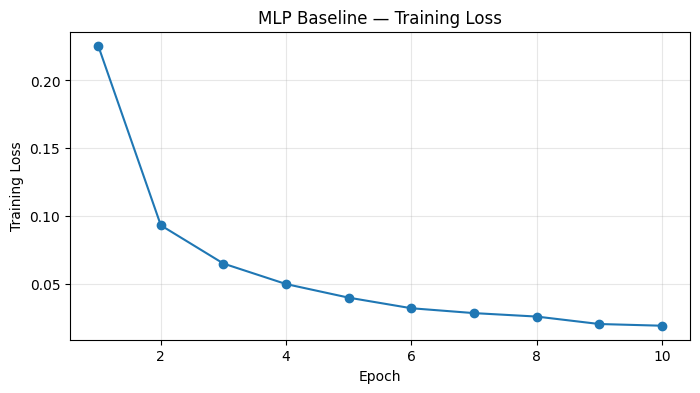

In [16]:
# Final evaluation
mlp_accuracy, mlp_preds, mlp_labels = evaluate(mlp_model, test_loader)
print(f"MLP final test accuracy: {mlp_accuracy:.4f}")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), mlp_loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Baseline — Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

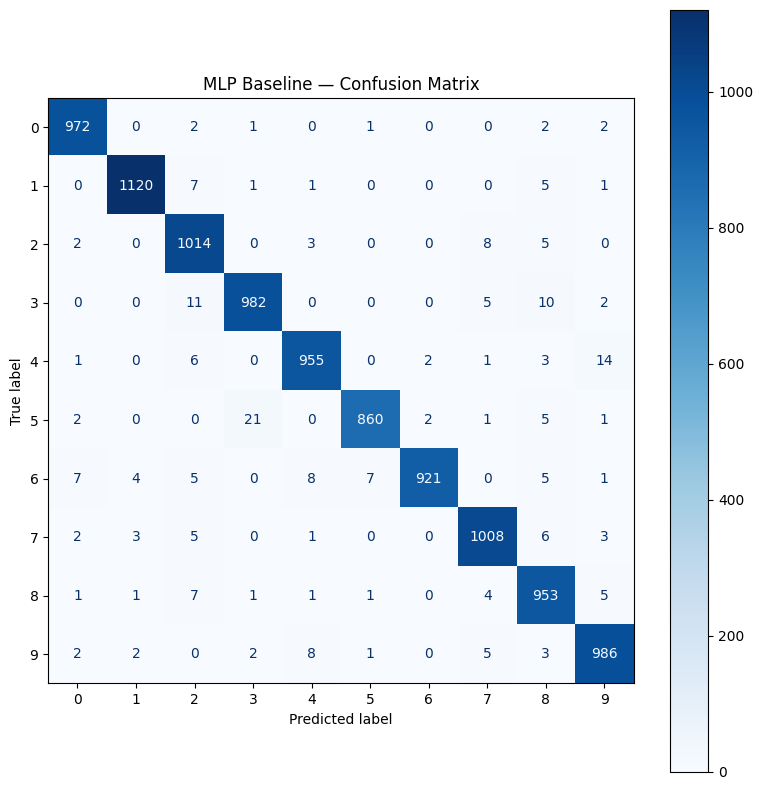

Saved mlp_confusion_matrix.png


In [17]:
# Confusion matrix
cm = confusion_matrix(mlp_labels, mlp_preds)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("MLP Baseline — Confusion Matrix")
plt.tight_layout()
plt.show()

# Save for MLflow logging later
fig.savefig("mlp_confusion_matrix.png", dpi=100, bbox_inches='tight')
print("Saved mlp_confusion_matrix.png")

### 2.4 MLflow Logging (Optional — Do This Now or in Part 6)

The cell below logs everything for this run. You can run it now or come back during Part 6. Either way, you'll need to do this for every experiment, so it's worth getting it working here first.

In [ ]:
# Part 2.4 is now active so the MLP baseline is logged the same way as the CNN baseline in Part 3.
# Make sure your MLflow tracking server/URI is configured from earlier labs before running this cell.
mlflow.set_experiment("Lab5-MNIST")

with mlflow.start_run(run_name="MLP-baseline"):
    # Parameters
    mlflow.log_param("model_type", "MLP")
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("num_epochs", num_epochs)
    mlflow.log_param("optimizer", "Adam")

    # Tag
    mlflow.set_tag("architecture", "MLP-784-256-128-10")

    # Metrics
    for epoch, loss_val in enumerate(mlp_loss_history, start=1):
        mlflow.log_metric("train_loss", loss_val, step=epoch)
    mlflow.log_metric("test_accuracy", mlp_accuracy)

    # Artifact
    mlflow.log_artifact("mlp_confusion_matrix.png")

    print(f"Logged MLP baseline: accuracy={mlp_accuracy:.4f}")

Logged MLP baseline: accuracy=0.9771


---

### What to reuse for Parts 3–5

When you build your CNN and run experiments, you should reuse:

- **`evaluate()`** — works with any model, no changes needed.
- **The training loop** — the only thing that changes is which model and optimizer you pass in. Consider wrapping it in a function:

```python
def train_model(model, train_loader, num_epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_history = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        loss_history.append(running_loss / len(train_loader))
    return loss_history
```

- **The confusion matrix code** — just change the filename and title.
- **The MLflow logging pattern** — change the run name, tag, and parameters.

---

## Part 3: CNN Classifier

Now build and train a CNN on the same data. You can use the `SimpleCNN` from the Day 2 in-class lab, or write your own architecture.

**Requirements:**

- At least two convolutional layers with ReLU and max pooling.
- A fully connected classification head that outputs 10 classes.
- Train using cross-entropy loss and an appropriate optimizer.
- Log the run to MLflow.
- Record the final test accuracy and compare to your MLP baseline.

The only thing that changes from Part 2 is the model definition. Your data loading, training loop, and evaluation code should be reusable. If they aren't, refactor them into a function.

In [ ]:
# Define your CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


cnn_model_simple_baseline = SimpleCNN()
cnn_simple_baseline_params = sum(p.numel() for p in cnn_model_simple_baseline.parameters())
print(cnn_model_simple_baseline)
print(f"Simple CNN parameters: {cnn_simple_baseline_params:,}")

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Simple CNN parameters: 206,922


In [23]:
# Train the CNN 
cnn_loss_history = train_model(
    cnn_model_simple_baseline,
    train_loader,
    test_loader,
    num_epochs=num_epochs,
    learning_rate=learning_rate,
)

Epoch [1/10]  Loss: 0.1582  Test Acc: 0.9832
Epoch [2/10]  Loss: 0.0509  Test Acc: 0.9844
Epoch [4/10]  Loss: 0.0257  Test Acc: 0.9875
Epoch [6/10]  Loss: 0.0159  Test Acc: 0.9879
Epoch [8/10]  Loss: 0.0095  Test Acc: 0.9914
Epoch [10/10]  Loss: 0.0064  Test Acc: 0.9901


CNN final test accuracy: 0.9901
MLP final test accuracy: 0.9771


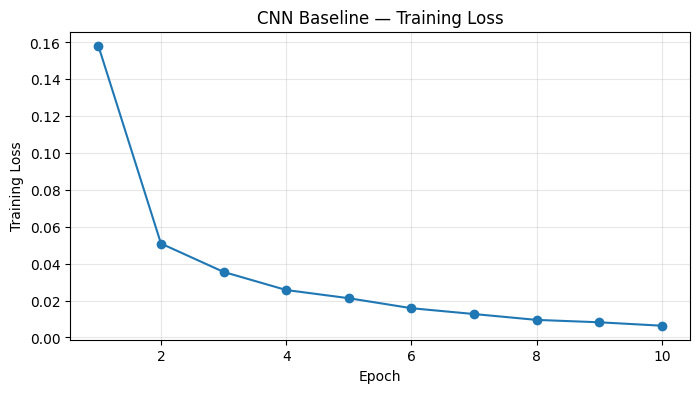

In [24]:
# Evaluate on the test set and print accuracy
# Added for Part 3: print the CNN result and compare it directly against the stored MLP baseline.
cnn_accuracy, cnn_preds, cnn_labels = evaluate(cnn_model_simple_baseline, test_loader)
print(f"CNN final test accuracy: {cnn_accuracy:.4f}")
print(f"MLP final test accuracy: {mlp_accuracy:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), cnn_loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Baseline — Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

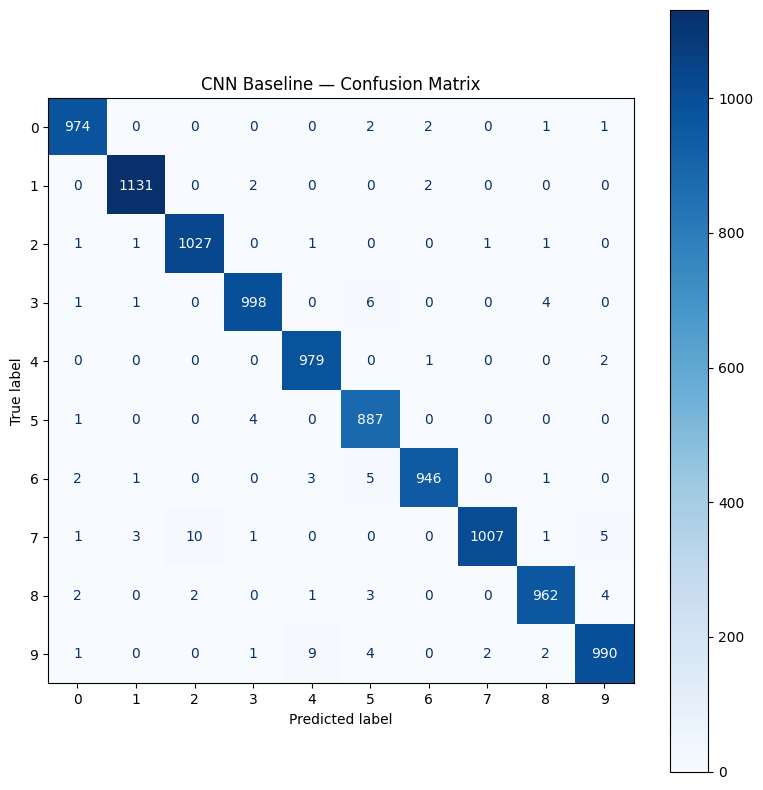

Saved cnn_baseline_confusion_matrix.png


In [25]:
# Confusion matrix
cm = confusion_matrix(cnn_labels, cnn_preds)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("CNN Baseline — Confusion Matrix")
plt.tight_layout()
plt.show()

# Save for MLflow logging later
fig.savefig("cnn_baseline_confusion_matrix.png", dpi=100, bbox_inches='tight')
print("Saved cnn_baseline_confusion_matrix.png")

In [26]:

mlflow.set_experiment("Lab5-MNIST")

with mlflow.start_run(run_name="CNN-baseline"):
    # Parameters
    mlflow.log_param("model_type", "CNN")
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("num_epochs", num_epochs)
    mlflow.log_param("optimizer", "Adam")

    # Tag 
    mlflow.set_tag("architecture", "CNN: Conv(1→16,3)-Pool-Conv(16→32,3)-Pool-FC(1568→128→10)")

    # Metrics
    for epoch, loss_val in enumerate(cnn_loss_history, start=1):
        mlflow.log_metric("train_loss", loss_val, step=epoch)
    mlflow.log_metric("test_accuracy", cnn_accuracy)

    # Artifact
    mlflow.log_artifact("cnn_baseline_confusion_matrix.png")

    print(f"Logged CNN baseline: accuracy={cnn_accuracy:.4f}")

Logged CNN baseline: accuracy=0.9901


## Part 4: Required Experiments — Kernel Size and Filter Counts

Modify the CNN architecture in at least **two** of the following ways. Each should be a separate MLflow run with a descriptive tag so you can compare them later.

**Choose at least two:**

- Change the convolutional kernel size (e.g., from 3×3 to 5×5).
- Change the number of filters (e.g., from 16→32 to 32→64, or reduce to 8→16).
- Try both changes together.

**Important:** if you change the kernel size or the number of pooling layers, the spatial dimensions at the flatten step will change. You need to recompute the input size for your first fully connected layer. Use the shape-tracing technique from the Day 2 lab.

For each experiment, record: what you changed, what you expected to happen, and what actually happened.

In [27]:
# Experiment 1 - Change the kernal size to 5

class SimpleCNNKernel5(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2) # With padding = 2, we don't need to change the shape
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


cnn_model_kernel5 = SimpleCNNKernel5()
cnn_kernel5_params = sum(p.numel() for p in cnn_model_kernel5.parameters())
print(cnn_model_kernel5)
print(f"Kernel-5 CNN parameters: {cnn_kernel5_params:,}")


SimpleCNNKernel5(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Kernel-5 CNN parameters: 215,370


In [28]:
# Train the CNN
cnn_kernel5_loss_history = train_model(
    cnn_model_kernel5,
    train_loader,
    test_loader,
    num_epochs=num_epochs,
    learning_rate=learning_rate,
)

Epoch [1/10]  Loss: 0.1393  Test Acc: 0.9862
Epoch [2/10]  Loss: 0.0462  Test Acc: 0.9876
Epoch [4/10]  Loss: 0.0241  Test Acc: 0.9899
Epoch [6/10]  Loss: 0.0149  Test Acc: 0.9913
Epoch [8/10]  Loss: 0.0123  Test Acc: 0.9911
Epoch [10/10]  Loss: 0.0088  Test Acc: 0.9911


CNN (5x5 kernels) final test accuracy: 0.9911
CNN baseline final test accuracy: 0.9901


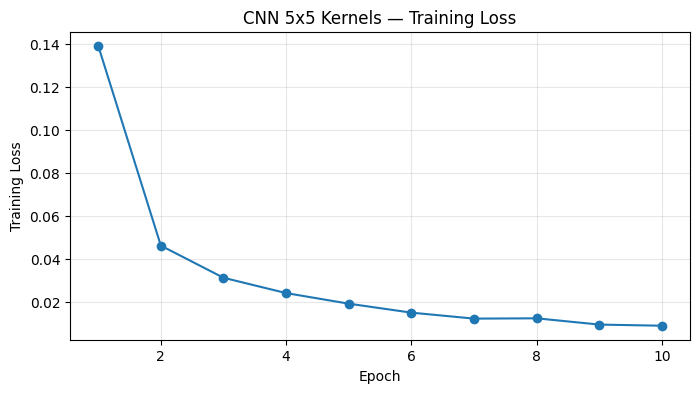

In [29]:
# Evaluate on the test set and print accuracy
cnn_kernel5_accuracy, cnn_kernel5_preds, cnn_kernel5_labels = evaluate(cnn_model_kernel5, test_loader)
print(f"CNN (5x5 kernels) final test accuracy: {cnn_kernel5_accuracy:.4f}")
print(f"CNN baseline final test accuracy: {cnn_accuracy:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), cnn_kernel5_loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN 5x5 Kernels — Training Loss")
plt.grid(True, alpha=0.3)
plt.show()


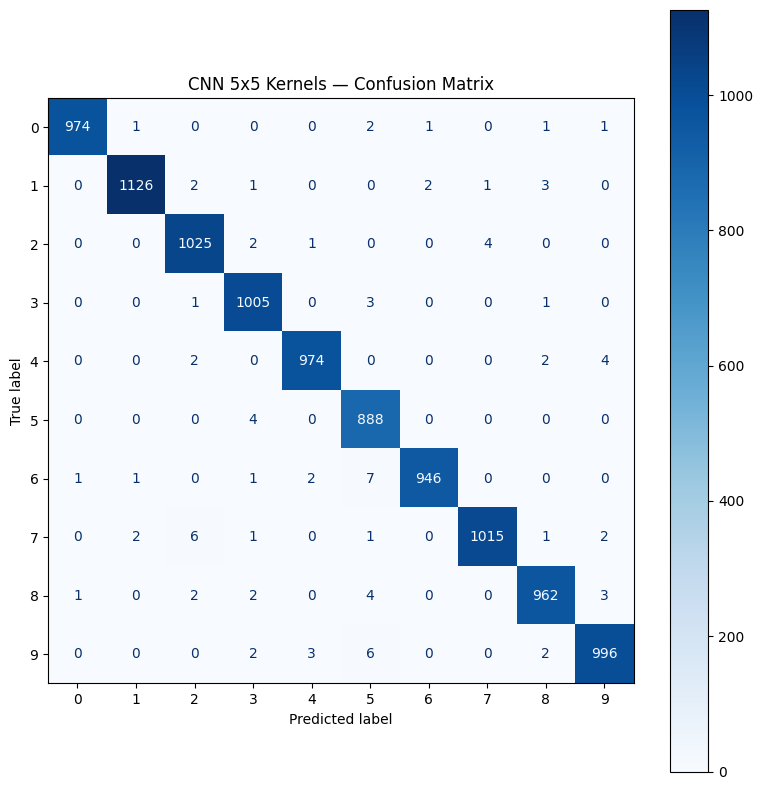

Saved cnn_kernel5_confusion_matrix.png


In [30]:
# Confusion matrix
cm = confusion_matrix(cnn_kernel5_labels, cnn_kernel5_preds)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("CNN 5x5 Kernels — Confusion Matrix")
plt.tight_layout()
plt.show()

# Save for MLflow logging later
fig.savefig("cnn_kernel5_confusion_matrix.png", dpi=100, bbox_inches='tight')
print("Saved cnn_kernel5_confusion_matrix.png")

In [31]:
mlflow.set_experiment("Lab5-MNIST")

with mlflow.start_run(run_name="CNN-kernel5"):
    # Parameters
    mlflow.log_param("model_type", "CNN")
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("num_epochs", num_epochs)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("kernel_size", 5)

    # Tag
    mlflow.set_tag("architecture", "CNN: Conv(1→16,5)-Pool-Conv(16→32,5)-Pool-FC(1568→128→10)")

    # Metrics
    for epoch, loss_val in enumerate(cnn_kernel5_loss_history, start=1):
        mlflow.log_metric("train_loss", loss_val, step=epoch)
    mlflow.log_metric("test_accuracy", cnn_kernel5_accuracy)

    # Artifact
    mlflow.log_artifact("cnn_kernel5_confusion_matrix.png")

    print(f"Logged CNN kernel-5 experiment: accuracy={cnn_kernel5_accuracy:.4f}")


Logged CNN kernel-5 experiment: accuracy=0.9911


In [32]:
# Experiment 2 - Increase number of filters to 32-64

# Define your CNN model
class SimpleCNNMoreFilters(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


cnn_model_more_filters = SimpleCNNMoreFilters()
cnn_more_filters_params = sum(p.numel() for p in cnn_model_more_filters.parameters())
print(cnn_model_more_filters)
print(f"CNN with more filters parameters: {cnn_more_filters_params:,}")


SimpleCNNMoreFilters(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
CNN with more filters parameters: 421,642


In [33]:
# Train the CNN 
cnn_more_filters_loss_history = train_model(
    cnn_model_more_filters,
    train_loader,
    test_loader,
    num_epochs=num_epochs,
    learning_rate=learning_rate,
)

Epoch [1/10]  Loss: 0.1375  Test Acc: 0.9861
Epoch [2/10]  Loss: 0.0441  Test Acc: 0.9890
Epoch [4/10]  Loss: 0.0215  Test Acc: 0.9899
Epoch [6/10]  Loss: 0.0136  Test Acc: 0.9897
Epoch [8/10]  Loss: 0.0095  Test Acc: 0.9901
Epoch [10/10]  Loss: 0.0077  Test Acc: 0.9910


CNN with more filters final test accuracy: 0.9910
CNN baseline final test accuracy: 0.9901


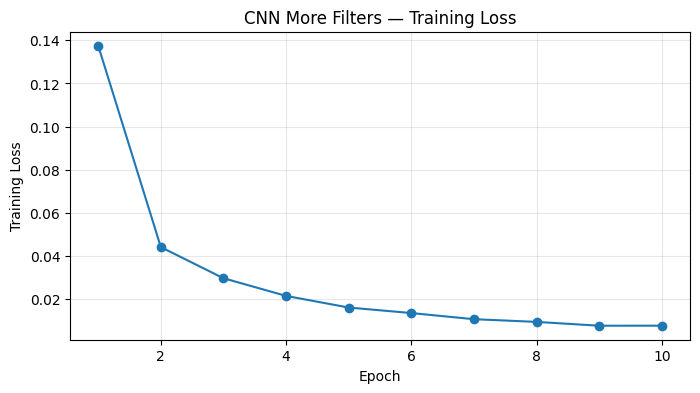

In [34]:
# Evaluate on the test set and print accuracy
cnn_more_filters_accuracy, cnn_more_filters_preds, cnn_more_filters_labels = evaluate(cnn_model_more_filters, test_loader)
print(f"CNN with more filters final test accuracy: {cnn_more_filters_accuracy:.4f}")
print(f"CNN baseline final test accuracy: {cnn_accuracy:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), cnn_more_filters_loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN More Filters — Training Loss")
plt.grid(True, alpha=0.3)
plt.show()


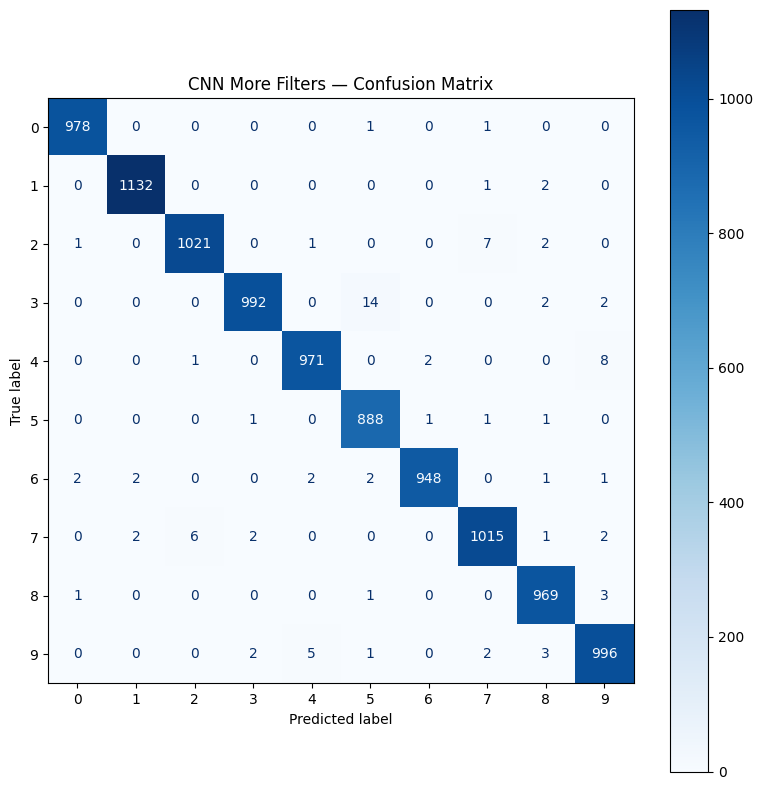

Saved cnn_more_filters_confusion_matrix.png


In [35]:
# Confusion matrix
cm = confusion_matrix(cnn_more_filters_labels, cnn_more_filters_preds)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("CNN More Filters — Confusion Matrix")
plt.tight_layout()
plt.show()

# Save for MLflow logging later
fig.savefig("cnn_more_filters_confusion_matrix.png", dpi=100, bbox_inches='tight')
print("Saved cnn_more_filters_confusion_matrix.png")


In [36]:
mlflow.set_experiment("Lab5-MNIST")

with mlflow.start_run(run_name="CNN-more-filters"):
    # Parameters
    mlflow.log_param("model_type", "CNN")
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("num_epochs", num_epochs)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("conv1_filters", 32)
    mlflow.log_param("conv2_filters", 64)

    # Tag 
    mlflow.set_tag("architecture", "CNN: Conv(1→32,3)-Pool-Conv(32→64,3)-Pool-FC(3136→128→10)")

    # Metrics
    for epoch, loss_val in enumerate(cnn_more_filters_loss_history, start=1):
        mlflow.log_metric("train_loss", loss_val, step=epoch)
    mlflow.log_metric("test_accuracy", cnn_more_filters_accuracy)

    # Artifact
    mlflow.log_artifact("cnn_more_filters_confusion_matrix.png")

    print(f"Logged CNN more-filters experiment: accuracy={cnn_more_filters_accuracy:.4f}")


Logged CNN more-filters experiment: accuracy=0.9910


## Part 5: Open Exploration

Try at least **one** additional modification beyond Part 4. Some ideas:

- Add dropout (`nn.Dropout` or `nn.Dropout2d`).
- Add batch normalization (`nn.BatchNorm2d`).
- Add a third convolutional block.
- Try a different optimizer (e.g., SGD with momentum vs. Adam).
- Experiment with learning rate schedules.
- Add data augmentation (random rotations, slight shifts) via `transforms`.
- Try a much deeper or much shallower architecture.

Log each experiment to MLflow. In your writeup, explain what you tried, what you expected to happen, and what actually happened.

In [37]:
# Open exploration experiment(s) - batch normalization and a third conv layer

# Define your CNN model
class SimpleCNNBatchNorm3Conv(nn.Module):
    def __init__(self):
        super().__init__()

        # First conv block
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)

        # Added for Part 5:
        # BatchNorm2d normalizes each channel's activations within a batch,
        # which often makes training more stable and can improve accuracy.
        self.bn1 = nn.BatchNorm2d(16)

        # Second conv block
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # Added for Part 5:
        # Third convolutional block to make the network deeper.
        # Since we keep padding=1 with kernel_size=3, conv layers preserve HxW.
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

        # Shape trace:
        # Input:                 1 x 28 x 28
        # After conv1 + pool:   16 x 14 x 14
        # After conv2 + pool:   32 x  7 x  7
        # After conv3:          64 x  7 x  7
        #
        # Note:
        # We do NOT pool after conv3, so the spatial size stays 7x7 here.
        # Because the third conv increases channels from 32 to 64,
        # the flatten size becomes 64 * 7 * 7 = 3136.
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


cnn_model_bn_3conv = SimpleCNNBatchNorm3Conv()
cnn_bn_3conv_params = sum(p.numel() for p in cnn_model_bn_3conv.parameters())
print(cnn_model_bn_3conv)
print(f"CNN with batch norm + third conv parameters: {cnn_bn_3conv_params:,}")


SimpleCNNBatchNorm3Conv(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
CNN with batch norm + third conv parameters: 426,346


In [38]:
# Train the CNN 
cnn_bn_3conv_loss_history = train_model(
    cnn_model_bn_3conv,
    train_loader,
    test_loader,
    num_epochs=num_epochs,
    learning_rate=learning_rate,
)


Epoch [1/10]  Loss: 0.0999  Test Acc: 0.9847
Epoch [2/10]  Loss: 0.0398  Test Acc: 0.9909
Epoch [4/10]  Loss: 0.0223  Test Acc: 0.9901
Epoch [6/10]  Loss: 0.0161  Test Acc: 0.9901
Epoch [8/10]  Loss: 0.0111  Test Acc: 0.9898
Epoch [10/10]  Loss: 0.0107  Test Acc: 0.9919


CNN with batch norm + third conv final test accuracy: 0.9919
CNN baseline final test accuracy: 0.9901


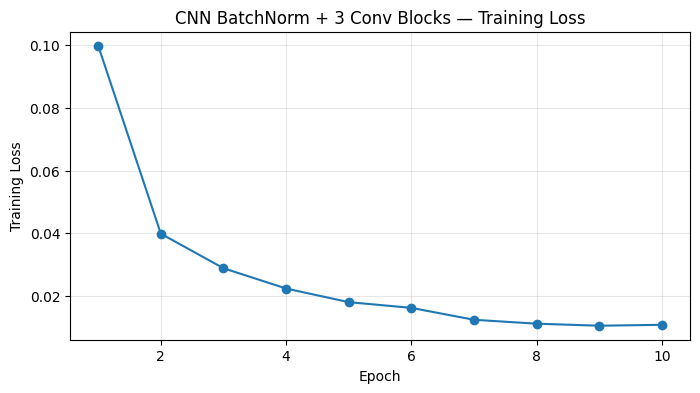

In [39]:
# Evaluate on the test set and print accuracy
cnn_bn_3conv_accuracy, cnn_bn_3conv_preds, cnn_bn_3conv_labels = evaluate(cnn_model_bn_3conv, test_loader)
print(f"CNN with batch norm + third conv final test accuracy: {cnn_bn_3conv_accuracy:.4f}")
print(f"CNN baseline final test accuracy: {cnn_accuracy:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), cnn_bn_3conv_loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN BatchNorm + 3 Conv Blocks — Training Loss")
plt.grid(True, alpha=0.3)
plt.show()


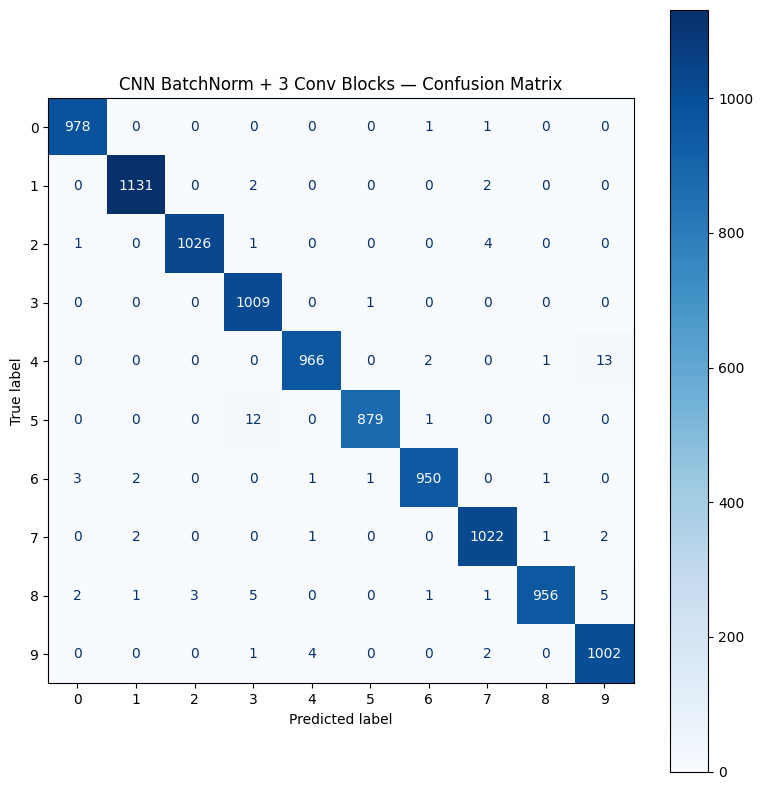

Saved cnn_bn_3conv_confusion_matrix.png


In [40]:
# Confusion matrix
cm = confusion_matrix(cnn_bn_3conv_labels, cnn_bn_3conv_preds)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("CNN BatchNorm + 3 Conv Blocks — Confusion Matrix")
plt.tight_layout()
plt.show()

# Save for MLflow logging later
fig.savefig("cnn_bn_3conv_confusion_matrix.png", dpi=100, bbox_inches='tight')
print("Saved cnn_bn_3conv_confusion_matrix.png")


In [41]:
mlflow.set_experiment("Lab5-MNIST")

with mlflow.start_run(run_name="CNN-batchnorm-3conv"):
    # Parameters
    mlflow.log_param("model_type", "CNN")
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("num_epochs", num_epochs)
    mlflow.log_param("optimizer", "Adam")

    # Added for Part 5:
    # Log the architectural changes explicitly so this run is easy to compare in MLflow.
    mlflow.log_param("batch_normalization", True)
    mlflow.log_param("num_conv_layers", 3)
    mlflow.log_param("conv1_filters", 16)
    mlflow.log_param("conv2_filters", 32)
    mlflow.log_param("conv3_filters", 64)

    # Tag 
    mlflow.set_tag("architecture", "CNN: Conv(1→16,3)-BN-Pool-Conv(16→32,3)-BN-Pool-Conv(32→64,3)-BN-FC(3136→128→10)")

    # Metrics
    for epoch, loss_val in enumerate(cnn_bn_3conv_loss_history, start=1):
        mlflow.log_metric("train_loss", loss_val, step=epoch)
    mlflow.log_metric("test_accuracy", cnn_bn_3conv_accuracy)

    # Artifact
    mlflow.log_artifact("cnn_bn_3conv_confusion_matrix.png")

    print(f"Logged CNN batch norm + third conv experiment: accuracy={cnn_bn_3conv_accuracy:.4f}")


Logged CNN batch norm + third conv experiment: accuracy=0.9919


## Part 6: MLflow Logging

Every training run (MLP baseline, base CNN, each experiment) must be logged to MLflow. For each run, log:

- **Parameters:** learning rate, batch size, number of epochs, optimizer name.
- **Tag:** a short architecture description (e.g., `"SimpleCNN"`, `"MLP-baseline"`, `"CNN-5x5kernels"`).
- **Metrics:** training loss per epoch, test accuracy at the end of training.
- **Artifact:** a confusion matrix saved as a `.png` file.

For the confusion matrix, use `sklearn.metrics.confusion_matrix` and `ConfusionMatrixDisplay`. Save the figure with `plt.savefig()` and log it with `mlflow.log_artifact()`. Refer to your earlier labs for the MLflow logging pattern.

If you haven't already been logging as you go in Parts 2–5, go back and add MLflow logging to each run now. It's much easier to log as you train than to reconstruct runs after the fact.

In [51]:
import pandas as pd
from mlflow.tracking import MlflowClient

mlflow.set_experiment("Lab5-MNIST")
client = MlflowClient()

experiment = client.get_experiment_by_name("Lab5-MNIST")
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.test_accuracy DESC"]
)

records = []
for run in runs:
    run_name = run.info.run_name
    architecture = run.data.tags.get("architecture")

    # Fill in architecture details for easy comparison.
    # If not explicitly changed, assume the Part 3 baseline setup:
    # kernel_size=3, padding=1, conv filters=16->32, conv layers=2, pooling layers=2.
    kernel_size = 3
    padding = 1
    conv_filters = "16->32"
    conv_layers = 2
    pooling_layers = 2

    if run_name == "CNN-kernel5":
        kernel_size = 5
        padding = 2
    elif run_name == "CNN-more-filters":
        conv_filters = "32->64"
    elif run_name == "CNN-batchnorm-3conv":
        conv_filters = "16->32->64"
        conv_layers = 3

    records.append({
        "run_name": run_name,
        "test_accuracy": run.data.metrics.get("test_accuracy"),
        "learning_rate": run.data.params.get("learning_rate"),
        "batch_size": run.data.params.get("batch_size"),
        "num_epochs": run.data.params.get("num_epochs"),
        "optimizer": run.data.params.get("optimizer"),
        "kernel_size": kernel_size,
        "padding": padding,
        "conv_filters": conv_filters,
        "conv_layers": conv_layers,
        "pooling_layers": pooling_layers,
        "architecture": architecture,
    })

results_df = pd.DataFrame(records)
results_df = results_df.sort_values("test_accuracy", ascending=False).reset_index(drop=True)

print("MLflow run summary (sorted by test accuracy):")
display(results_df)

# Brief comparison of the best runs
best_run = results_df.iloc[0]
baseline_cnn_row = results_df[results_df["run_name"] == "CNN-baseline"].iloc[0]
mlp_row = results_df[results_df["run_name"] == "MLP-baseline"].iloc[0]

print(f"Best run: {best_run['run_name']} with test accuracy = {best_run['test_accuracy']:.4f}")
print(f"Baseline CNN accuracy: {baseline_cnn_row['test_accuracy']:.4f}")
print(f"MLP baseline accuracy: {mlp_row['test_accuracy']:.4f}")
print()

MLflow run summary (sorted by test accuracy):


,run_name,test_accuracy,learning_rate,batch_size,num_epochs,optimizer,kernel_size,padding,conv_filters,conv_layers,pooling_layers,architecture
0,CNN-batchnorm-3conv,0.9919,0.001,64,10,Adam,3,1,16->32->64,3,2,"CNN: Conv(1→16,3)-BN-Pool-Conv(16→32,3)-BN-Poo..."
1,CNN-kernel5,0.9911,0.001,64,10,Adam,5,2,16->32,2,2,"CNN: Conv(1→16,5)-Pool-Conv(16→32,5)-Pool-FC(1..."
2,CNN-more-filters,0.9910,0.001,64,10,Adam,3,1,32->64,2,2,"CNN: Conv(1→32,3)-Pool-Conv(32→64,3)-Pool-FC(3..."
3,CNN-baseline,0.9901,0.001,64,10,Adam,3,1,16->32,2,2,"CNN: Conv(1→16,3)-Pool-Conv(16→32,3)-Pool-FC(1..."
4,MLP-baseline,0.9771,0.001,64,10,Adam,3,1,16->32,2,2,MLP-784-256-128-10


Best run: CNN-batchnorm-3conv with test accuracy = 0.9919
Baseline CNN accuracy: 0.9901
MLP baseline accuracy: 0.9771



## Part 7: Visualization

After training your best CNN, visualize what it has learned. Work through the **CNN Visualization Tutorial** notebook (`cnn_visualization_tutorial.ipynb`) first — it walks through every technique on a FashionMNIST model with full working code. Then come back here and adapt the code to your MNIST model.

You need to produce two visualizations:

1. **Learned conv1 filters** — display the first layer's weights as a grid of small grayscale images.
2. **Intermediate feature maps** — pass a single MNIST digit through your model layer by layer and display the feature maps after each conv layer.

The tutorial notebook has all the code you need; the only changes are your model variable name and layer names.

conv1 weight shape: torch.Size([16, 1, 3, 3])

  out_channels = 16  (number of filters)
  in_channels  = 1   (channels per filter — 1 for grayscale)
  kernel_size  = (3, 3)

So we have 16 filters, each of size 1×3×3.
Since in_channels=1, each filter is just a 3×3 2D image.


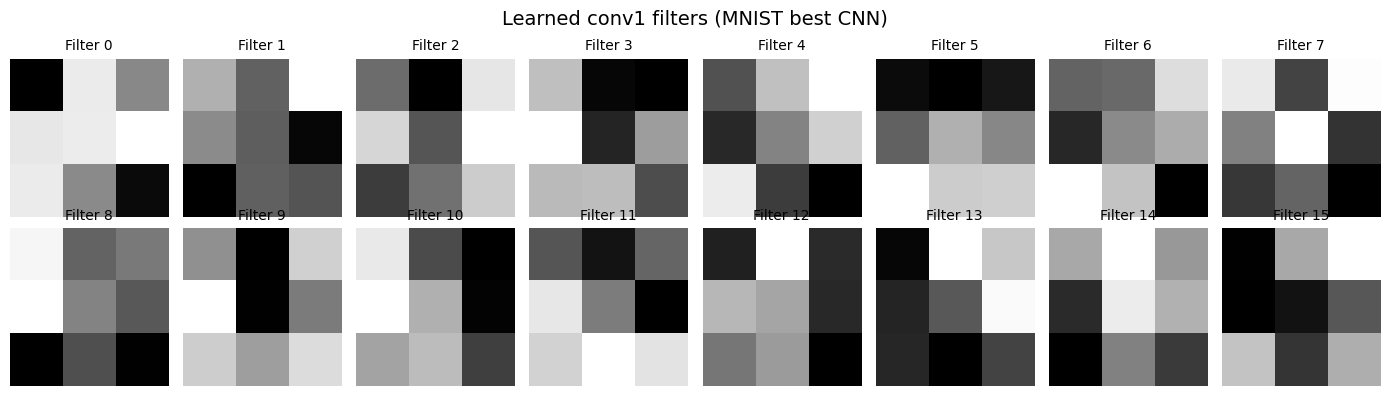

Filter 0 values:
[[-0.343  0.178 -0.04 ]
 [ 0.169  0.179  0.223]
 [ 0.178 -0.037 -0.319]]

Filter 1 values:
[[ 0.172 -0.017  0.366]
 [ 0.084 -0.026 -0.241]
 [-0.256 -0.021 -0.05 ]]


In [43]:
# Visualize learned conv1 filters
# (Adapt from Part 1 of the visualization tutorial)

weights = cnn_model_bn_3conv.conv1.weight.data.cpu()

print(f"conv1 weight shape: {weights.shape}")
print()

# Unpack the dimensions
out_ch, in_ch, kH, kW = weights.shape
print(f"  out_channels = {out_ch}  (number of filters)")
print(f"  in_channels  = {in_ch}   (channels per filter — 1 for grayscale)")
print(f"  kernel_size  = ({kH}, {kW})")
print()
print(f"So we have {out_ch} filters, each of size {in_ch}×{kH}×{kW}.")
print(f"Since in_channels=1, each filter is just a {kH}×{kW} 2D image.")

# Plot all conv1 filters
n = weights.shape[0]
rows = (n + 7) // 8
fig, axes = plt.subplots(rows, 8, figsize=(14, 2 * rows))

# Make axes iterable even if rows == 1
axes = np.array(axes).reshape(rows, 8)

for i, ax in enumerate(axes.flat):
    if i < weights.shape[0]:
        # weights[i] has shape (1, 3, 3) — squeeze out the channel dim
        filt = weights[i].squeeze().numpy()
        ax.imshow(filt, cmap='gray')
        ax.set_title(f"Filter {i}", fontsize=10)
    ax.axis('off')

plt.suptitle("Learned conv1 filters (MNIST best CNN)", fontsize=14)
plt.tight_layout()
plt.show()

# Also print the raw values of a few filters
print("Filter 0 values:")
print(weights[0].squeeze().numpy().round(3))
print()
print("Filter 1 values:")
print(weights[1].squeeze().numpy().round(3))



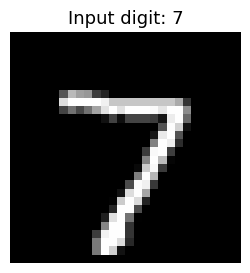

Input tensor shape: torch.Size([1, 28, 28])
Input:           torch.Size([1, 1, 28, 28])
After conv1:     torch.Size([1, 16, 28, 28])
After relu1:     torch.Size([1, 16, 28, 28])
After pool1:     torch.Size([1, 16, 14, 14])
After conv2:     torch.Size([1, 32, 14, 14])
After relu2:     torch.Size([1, 32, 14, 14])
After pool2:     torch.Size([1, 32, 7, 7])
After conv3:     torch.Size([1, 64, 7, 7])
After relu3:     torch.Size([1, 64, 7, 7])


In [45]:
# Visualize intermediate feature maps on a sample MNIST digit
# (Adapt from Part 2 of the visualization tutorial)

# Grab a test image
test_images, test_labels = next(iter(test_loader))
sample_img = test_images[0]   # shape: (1, 28, 28)
sample_label = test_labels[0]

# Show the original image
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(sample_img.squeeze().numpy(), cmap='gray')
ax.set_title(f"Input digit: {sample_label.item()}", fontsize=13)
ax.axis('off')
plt.show()

print(f"Input tensor shape: {sample_img.shape}")

cnn_model_bn_3conv.eval()

# Add batch dimension: (1, 28, 28) -> (1, 1, 28, 28)
x = sample_img.unsqueeze(0)
print(f"Input:           {x.shape}")

# Layer by layer
after_conv1 = cnn_model_bn_3conv.conv1(x)
print(f"After conv1:     {after_conv1.shape}")

after_bn1 = cnn_model_bn_3conv.bn1(after_conv1)
after_relu1 = cnn_model_bn_3conv.relu(after_bn1)
print(f"After relu1:     {after_relu1.shape}")

after_pool1 = cnn_model_bn_3conv.pool(after_relu1)
print(f"After pool1:     {after_pool1.shape}")

after_conv2 = cnn_model_bn_3conv.conv2(after_pool1)
print(f"After conv2:     {after_conv2.shape}")

after_bn2 = cnn_model_bn_3conv.bn2(after_conv2)
after_relu2 = cnn_model_bn_3conv.relu(after_bn2)
print(f"After relu2:     {after_relu2.shape}")

after_pool2 = cnn_model_bn_3conv.pool(after_relu2)
print(f"After pool2:     {after_pool2.shape}")

after_conv3 = cnn_model_bn_3conv.conv3(after_pool2)
print(f"After conv3:     {after_conv3.shape}")

after_bn3 = cnn_model_bn_3conv.bn3(after_conv3)
after_relu3 = cnn_model_bn_3conv.relu(after_bn3)
print(f"After relu3:     {after_relu3.shape}")


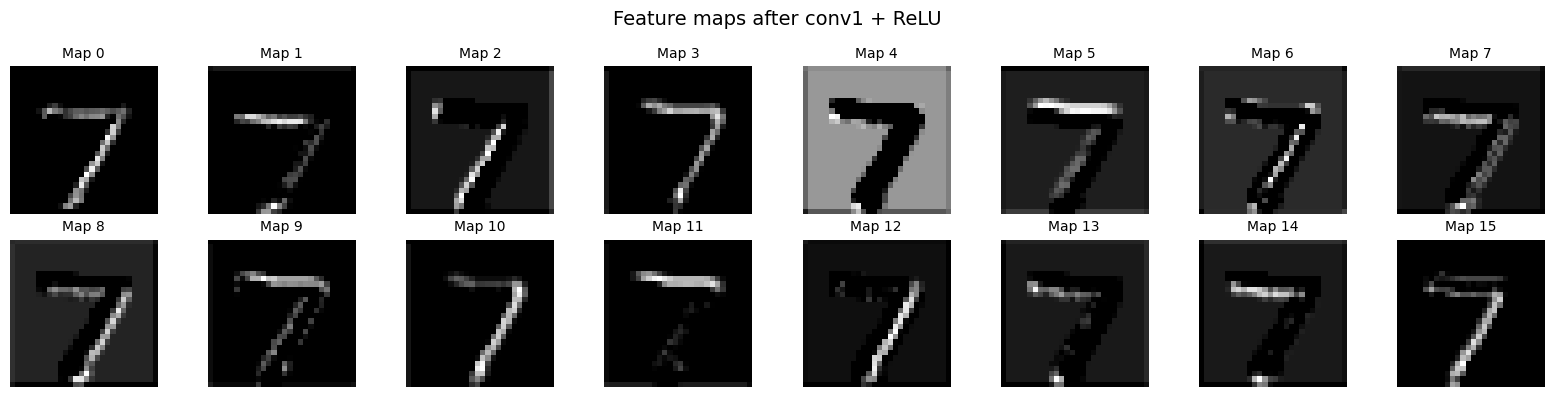

In [46]:

# Visualize feature maps after conv1 + relu
feature_maps1 = after_relu1.squeeze().detach().numpy()  # (16, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i < feature_maps1.shape[0]:
        ax.imshow(feature_maps1[i], cmap='gray')
        ax.set_title(f"Map {i}", fontsize=10)
    ax.axis('off')

plt.suptitle("Feature maps after conv1 + ReLU", fontsize=14)
plt.tight_layout()
plt.show()


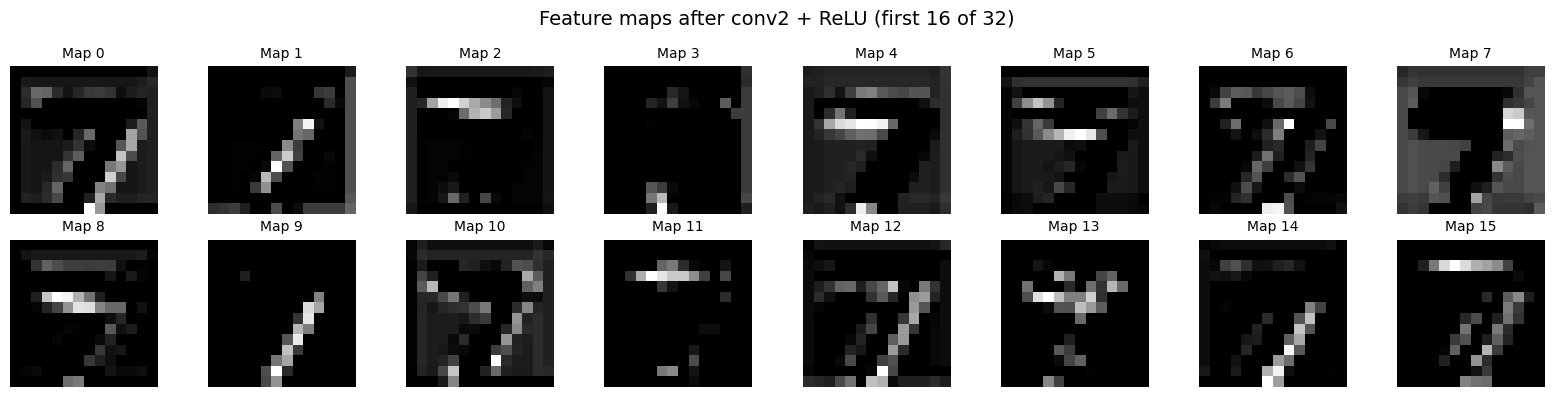

In [47]:

# Visualize 16 of the 32 feature maps after conv2 + relu
feature_maps2 = after_relu2.squeeze().detach().numpy()  # (32, 14, 14)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i < 16:
        ax.imshow(feature_maps2[i], cmap='gray')
        ax.set_title(f"Map {i}", fontsize=10)
    ax.axis('off')

plt.suptitle("Feature maps after conv2 + ReLU (first 16 of 32)", fontsize=14)
plt.tight_layout()
plt.show()


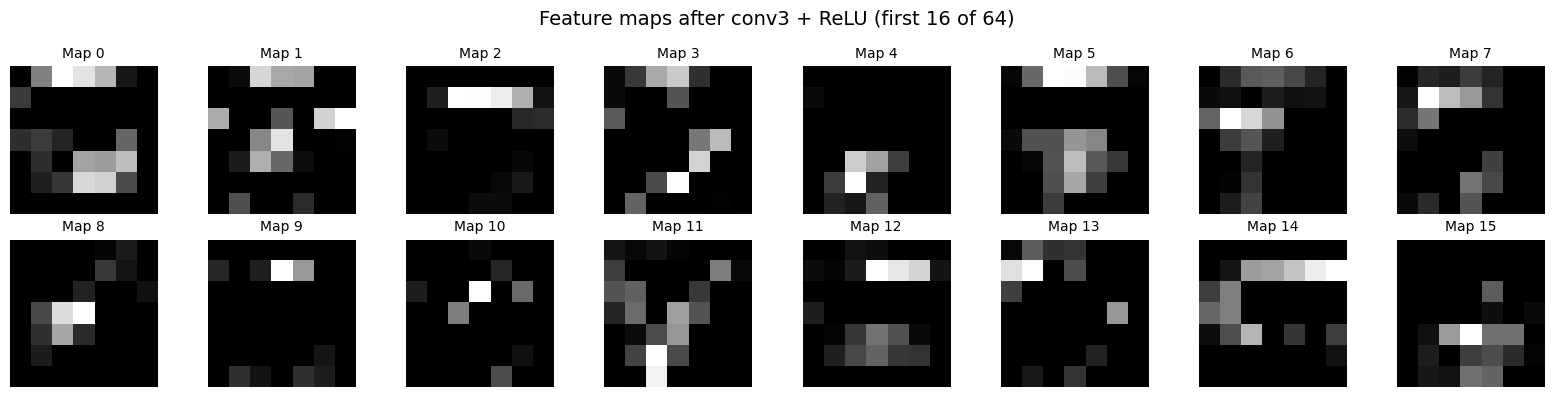

In [48]:

# Visualize 16 of the 64 feature maps after conv3 + relu
feature_maps3 = after_relu3.squeeze().detach().numpy()  # (64, 7, 7)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i < 16:
        ax.imshow(feature_maps3[i], cmap='gray')
        ax.set_title(f"Map {i}", fontsize=10)
    ax.axis('off')

plt.suptitle("Feature maps after conv3 + ReLU (first 16 of 64)", fontsize=14)
plt.tight_layout()
plt.show()


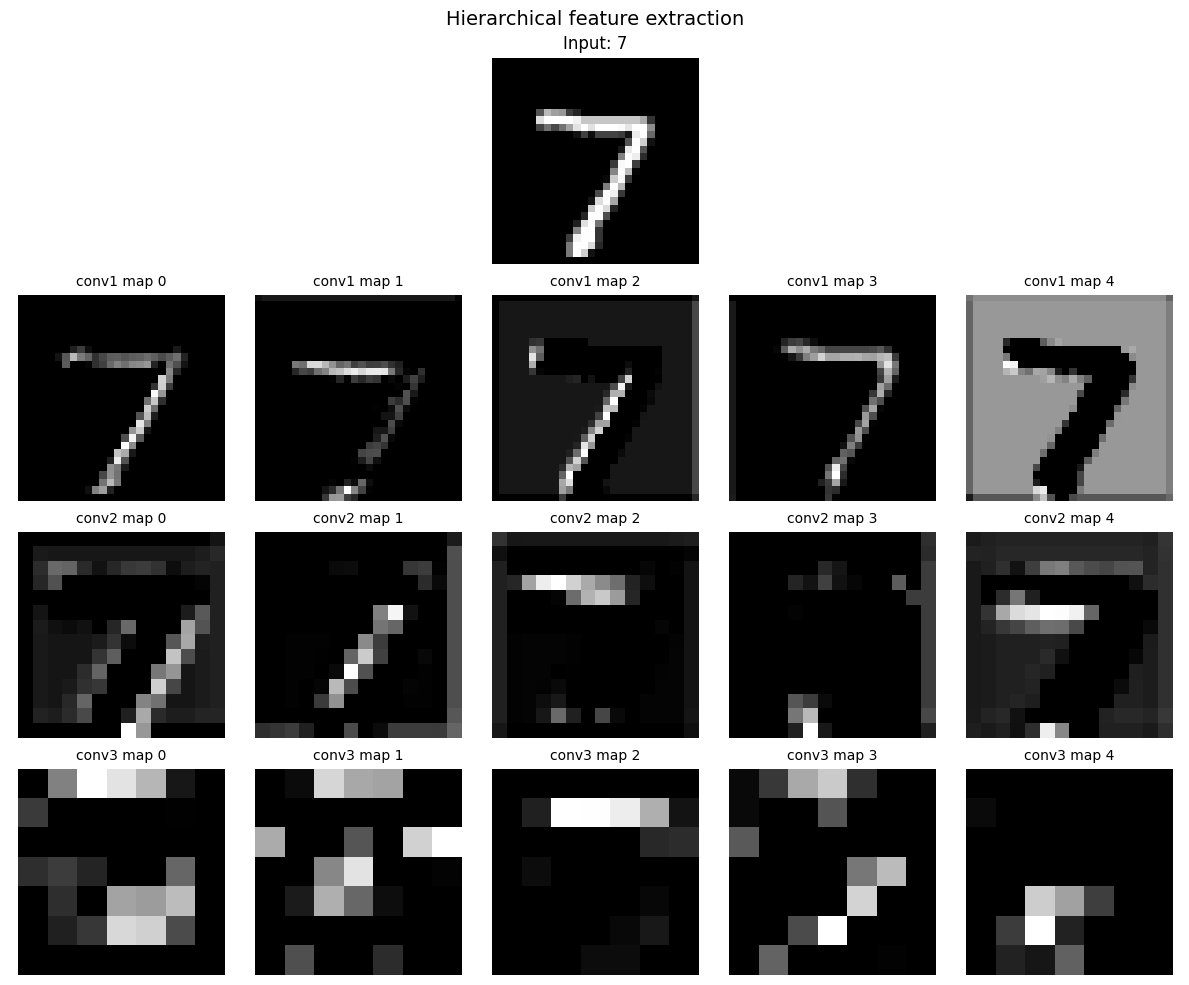

In [49]:

# Side-by-side: input -> conv1 -> conv2 -> conv3
fig, axes = plt.subplots(4, 5, figsize=(12, 10))

# Row 0: original image (centered)
for ax in axes[0]:
    ax.axis('off')
axes[0][2].imshow(sample_img.squeeze().numpy(), cmap='gray')
axes[0][2].set_title(f"Input: {sample_label.item()}", fontsize=12)

# Row 1: 5 feature maps from conv1
for i in range(5):
    axes[1][i].imshow(feature_maps1[i], cmap='gray')
    axes[1][i].set_title(f"conv1 map {i}", fontsize=10)
    axes[1][i].axis('off')

# Row 2: 5 feature maps from conv2
for i in range(5):
    axes[2][i].imshow(feature_maps2[i], cmap='gray')
    axes[2][i].set_title(f"conv2 map {i}", fontsize=10)
    axes[2][i].axis('off')

# Row 3: 5 feature maps from conv3
for i in range(5):
    axes[3][i].imshow(feature_maps3[i], cmap='gray')
    axes[3][i].set_title(f"conv3 map {i}", fontsize=10)
    axes[3][i].axis('off')

plt.suptitle("Hierarchical feature extraction", fontsize=14)
plt.tight_layout()
plt.show()


---

## Deliverables

Submit two files:

### 1. This notebook (`.ipynb`)

Your complete, executed notebook containing all code, outputs, and results for Parts 1–7. The notebook should run top to bottom without errors.

### 2. Writeup (`.md` or `.pdf`)

A short report (1–2 pages) covering:

- **Baseline comparison:** MLP vs. base CNN — what was the accuracy difference? Why does the CNN do better (or not)?
- **Experiment summary:** A table of all your MLflow runs showing architecture, key hyperparameters, and test accuracy.
- **Analysis of experiments:** For each experiment in Parts 4 and 5, what did you change, what did you expect, and what happened? Reference your MLflow metrics.
- **Visualization discussion:** What do the learned filters look like? How do the feature maps relate to the input?
- **Reflection:** What surprised you? If you had another week, what would you try next?

---

## Grading Rubric

| Component | Points |
|-----------|--------|
| CNN classifier (working, logged) | 20 |
| Kernel size / filter count experiments (at least two, logged) | 20 |
| Open exploration (at least one, logged) | 20 |
| MLflow logging (all runs, parameters, tags, confusion matrices) | 20 |
| Visualization (learned filters + intermediate feature maps) | 20 |
| Writeup (comparison, analysis, reflection) | 50 |
| **Total** | **150** |

---

## Tips

- **Start with Part 2.** If your MLP training loop works, everything else is a model swap.
- **Reuse code.** Write a `train_and_evaluate` function that takes a model, trains it, evaluates it, and logs everything to MLflow. Then call it for each experiment. You'll thank yourself.
- **Track your shapes.** Most CNN bugs are shape mismatches. Print `x.shape` after each layer, or use the shape-tracing technique from Day 2.
- **Don't overtrain.** MNIST is a small dataset. If your model isn't converging in 5–10 epochs, something is wrong with the setup, not the number of epochs.
- **Name your MLflow runs.** Future-you will thank present-you when comparing 8 runs in the MLflow UI.